In [1]:
import os
import sys
import torch

sys.path.append(os.path.abspath(".."))
from seismic_facies.models.unet import model as unet_model
from seismic_facies.procs.helper import set_seed, select_device
from seismic_facies.procs import dataset, dataloader
from seismic_facies.viz import viz_unet
from seismic_facies.models import metrics

In [2]:
set_seed(42)
device = select_device()

No GPU available!


In [3]:
unet = unet_model.UNet(in_channels=1, n_classes=6).to(device)


In [4]:
model_save_name = 'unet_new_seis_class_256_dice0.3fix.pt'           # .pt and .pth are common file extensions for saving models in pytorch
weights_dir = os.path.join(os.path.abspath('..'), 'seismic_facies/models_weights')
data_path = os.path.join(weights_dir, model_save_name)
unet.load_state_dict(torch.load(data_path, map_location=device))

<All keys matched successfully>

In [5]:
data_path = 'test_once/test1_seismic.npy'
label_path = 'test_once/test1_labels.npy'

In [6]:
test_dataset = dataset.SeismicSliceDataset(seismic_path=data_path, labels_path=label_path, mode="both")
test_dataset

In [7]:
batch_size = 12
test_loader = dataloader.create_dataloader_with_direction_batches(test_dataset, batch_size)
test_loader

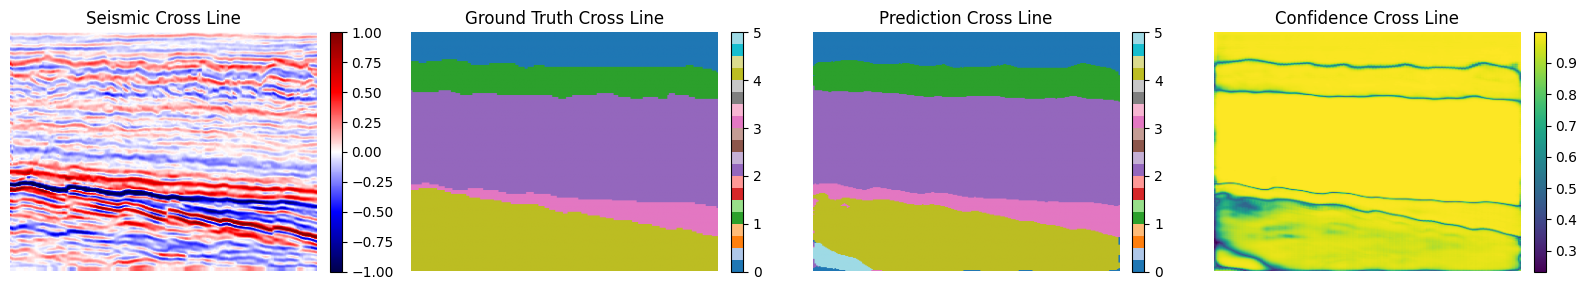

In [8]:
viz_unet.plot_segmentation_batch(
    model=unet,
    data_loader=test_loader,
    device=device,
    batch_idx=50,
    n_samples=1
)

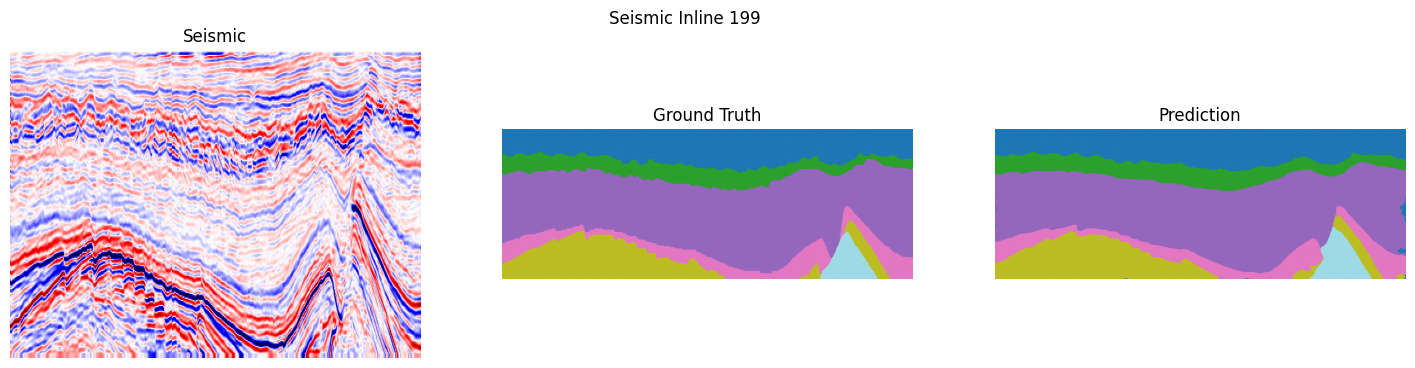

In [9]:
il_to_plot = 199
tp_to_plot = "Inline"
viz_unet.plot_sample_by_index(unet, test_dataset, device, idx=il_to_plot, title=f"Seismic {tp_to_plot} {il_to_plot}")

In [9]:
scores, cls_iou = metrics.evaluate_metrics_streaming(
    model=unet,
    data_loader=test_loader,
    device=device,
    n_classes=6
)

print(f"Pixel Acc: {scores["Pixel Acc: "]}")
print("Class Acc: ")
for i in range(scores["Class Accuracy: "].shape[0]):
    print(f"Class {i} Acc: {scores["Class Accuracy: "][i]}")
print(f"Mean Class Acc: {scores["Mean Class Acc: "]}")
print(f"Freq Weighted IoU: {scores["Freq Weighted IoU: "]}")
print(f"Mean IoU: {scores["Mean IoU: "]}")
print("Per-class IoU:")
for k, v in cls_iou.items():
    print(f"Class {k} IoU: {v}")

Pixel Acc: 0.8915943330256496
Class Acc: 
Class 0 Acc: 0.9766963815054268
Class 1 Acc: 0.9531261681544282
Class 2 Acc: 0.9659724565070238
Class 3 Acc: 0.8709208803967478
Class 4 Acc: 0.5809788290236494
Class 5 Acc: 0.8153040873604798
Mean Class Acc: 0.8604998004912927
Freq Weighted IoU: 0.8092432822662263
Mean IoU: 0.7163554288052256
Per-class IoU:
Class 0 IoU: 0.8317275355708792
Class 1 IoU: 0.8063524780838618
Class 2 IoU: 0.9297670708837205
Class 3 IoU: 0.6528774335990482
Class 4 IoU: 0.5625507925258764
Class 5 IoU: 0.5148572621679676


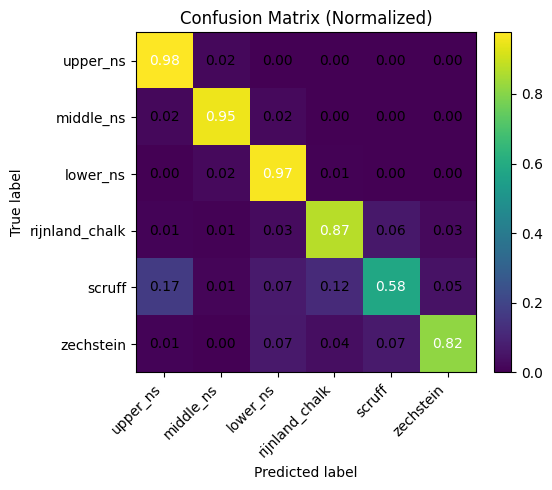

In [10]:
class_names = ['upper_ns', 'middle_ns', 'lower_ns',
                   'rijnland_chalk', 'scruff', 'zechstein']

cm_1 = scores["confusion_matrix"]
metrics.plot_confusion_matrix(cm_1, class_names=class_names, normalize=True)